# Arabic Handwritten Word Recognition
### Uses the proven CNN from ArabicHandwrittenCharacters.ipynb + YOLO for detection

**How it works:**
1. Train CNN on Arabic MNIST dataset (same as the working isolated character notebook)
2. Train YOLO on your 73 annotated word images to detect character locations
3. Feed each YOLO crop through the CNN using the exact same preprocessing that works on isolated characters
4. Output the recognised characters right-to-left

## 1. Install & Import

In [1]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow tqdm

In [2]:
import numpy as np
import cv2
import os
import re
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
from ultralytics import YOLO

# ── Paths — adjust if needed ─────────────────────────────────
ROOT       = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN")
TRAIN_PATH = ROOT / "arabic-chars-mnist" / "train"
TEST_PATH  = ROOT / "arabic-chars-mnist" / "test"
MY_DATASET = ROOT / "my_dataset"

# The 28 Arabic letter names — alphabetical order matches LabelEncoder
ARABIC_LABELS = [
    'ain', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'heh', 'jeem',
    'kaf', 'khah', 'lam', 'meem', 'noon', 'qaf', 'reh', 'sad', 'seen', 'sheen',
    'tah', 'teh', 'thal', 'theh', 'waw', 'yeh', 'zah', 'zain'
]

print(f"TensorFlow: {tf.__version__}")
for p in [TRAIN_PATH, TEST_PATH, MY_DATASET]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

TensorFlow: 2.21.0
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\arabic-chars-mnist\train
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\arabic-chars-mnist\test
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## 2. Load & Preprocess Arabic MNIST Dataset

In [3]:
def dataset_labels(path):
    data = []
    for filename in os.listdir(path):
        img_label = re.sub('[0-9]+|\.jpg$', '', filename)
        img_path  = os.path.join(path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            data.append((img, img_label))
    return data

print("Loading dataset...")
train_dataset = dataset_labels(str(TRAIN_PATH))
test_dataset  = dataset_labels(str(TEST_PATH))
print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}")

Loading dataset...
Train: 13440  Test: 3360


In [4]:
# Separate images and labels
train_img   = [d[0] for d in train_dataset]
train_label = [d[1] for d in train_dataset]
test_img    = [d[0] for d in test_dataset]
test_label  = [d[1] for d in test_dataset]

# Encode labels
lb = LabelEncoder()
train_label = lb.fit_transform(train_label)
test_label  = lb.transform(test_label)

# Shuffle
train_shuffled, train_labels_shuffled = shuffle(train_img,  train_label,  random_state=42)
test_shuffled,  test_labels_shuffled  = shuffle(test_img,   test_label,   random_state=42)

# Convert to numpy and normalise
train = np.array(train_shuffled).astype('float32') / 255.0
test  = np.array(test_shuffled).astype('float32')  / 255.0
train_labels = np.array(train_labels_shuffled)
test_labels  = np.array(test_labels_shuffled)

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
print(f"Classes    : {len(lb.classes_)} → {list(lb.classes_)}")

Train shape: (13440, 32, 32, 3)
Test shape : (3360, 32, 32, 3)
Classes    : 28 → [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]


## 3. Train CNN — Same Architecture as Working Notebook

In [5]:
model = Sequential([
    Conv2D(16, (3,3), strides=1, activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32, (3,3), strides=1, activation='relu'),
    MaxPool2D(2, 2),
    BatchNormalization(),

    Conv2D(64,  (3,3), strides=1, activation='relu'),
    Conv2D(128, (3,3), strides=1, activation='relu'),
    MaxPool2D(2, 2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l1_l2(l1=0.0001, l2=0.0001)),
    Dropout(0.5),
    Dense(28, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,420 (1.95 MB)

 Trainable params: 511,100 (1.95 MB)

 Non-trainable params: 320 (1.25 KB)

In [6]:
callbacks = [
    ModelCheckpoint('Deep_Learning.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train, train_labels,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

loss, acc = model.evaluate(test, test_labels, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2450 - loss: 3.6462
Epoch 1: val_accuracy improved from None to 0.03571, saving model to Deep_Learning.keras

Epoch 1: finished saving model to Deep_Learning.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3870 - loss: 2.9621 - val_accuracy: 0.0357 - val_loss: 8.3825
Epoch 2/20
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6979 - loss: 1.7504
Epoch 2: val_accuracy improved from 0.03571 to 0.37574, saving model to Deep_Learning.keras

Epoch 2: finished saving model to Deep_Learning.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7343 - loss: 1.6196 - val_accuracy: 0.3757 - val_loss: 4.1291
Epoch 3/20
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8289 - loss: 1.2476
Epoch 3: val_accuracy improved from 0.37574 to 0.85714, saving model to Deep_Learning.keras

Epoch 3: finished saving model to Deep_Learning.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8387 - l

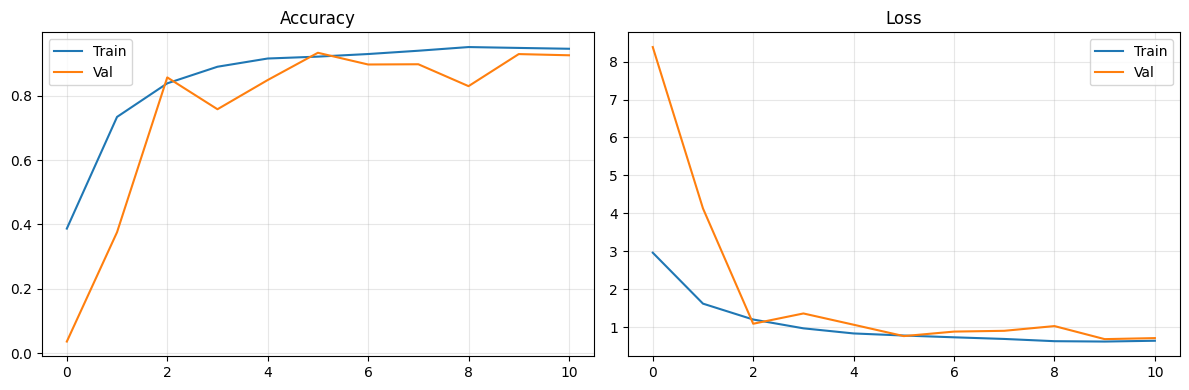

              precision    recall  f1-score   support

         ain       0.76      0.99      0.86       120
        alef       0.97      0.97      0.97       120
         beh       0.96      0.99      0.98       120
         dad       0.98      0.88      0.93       120
         dal       0.95      0.90      0.92       120
         feh       0.84      0.97      0.90       120
       ghain       0.92      0.93      0.92       120
         hah       0.93      0.87      0.90       120
         heh       0.99      0.86      0.92       120
        jeem       0.97      0.95      0.96       120
         kaf       0.94      0.98      0.96       120
        khah       0.99      0.90      0.94       120
         lam       0.97      0.99      0.98       120
        meem       0.98      0.95      0.97       120
        noon       0.97      0.86      0.91       120
         qaf       0.94      0.93      0.94       120
         reh       0.83      1.00      0.91       120
         sad       0.95    

In [7]:
# Plot history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Classification report
preds = np.argmax(model.predict(test, verbose=0), axis=1)
print(classification_report(test_labels, preds, target_names=ARABIC_LABELS))

## 4. Train YOLO — Single-Class Character Detector
Uses your 73 annotated word images. YOLO only needs to find WHERE characters are — CNN handles what they ARE.

In [8]:
# Convert all label files to single class (class_id = 0)
def convert_to_single_class(dataset_dir):
    for split in ['train', 'val']:
        labels_dir = Path(dataset_dir) / split / 'labels'
        if not labels_dir.exists():
            continue
        count = 0
        for txt in labels_dir.glob('*.txt'):
            lines = txt.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  {split}: converted {count} files")

print("Converting to single-class...")
convert_to_single_class(MY_DATASET)

train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train: {len(train_imgs)} images   Val: {len(val_imgs)} images")

Converting to single-class...
  train: converted 60 files
  val: converted 13 files
Train: 60 images   Val: 13 images


In [9]:
# Write data.yaml
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n  - character\n")
print(open(yaml_path).read())

path: F:/bach2/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



In [10]:
# Train YOLO
yolo_model = YOLO('yolov8s.pt')
yolo_model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=4,
    patience=30,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")

New https://pypi.org/project/ultralytics/8.4.27 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0

## 5. Inference Pipeline
The preprocessing here is **identical** to the working isolated character notebook — this is the key to accuracy.

In [34]:
# Load models
YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = load_model('Deep_Learning.keras')
yolo_detector = YOLO(str(YOLO_WEIGHTS))

print("CNN loaded: Deep_Learning.keras")
print(f"YOLO loaded: {YOLO_WEIGHTS}")

CNN loaded: Deep_Learning.keras
YOLO loaded: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt


In [21]:
import os
print(os.getcwd())
import glob
print(glob.glob("*.npy"))

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
['label_classes.npy']


In [35]:
def preprocess_crop_for_cnn(crop_bgr):
    """
    Exact same preprocessing as the working isolated character notebook.
    Input : BGR crop from YOLO bounding box
    Output: (1, 32, 32, 3) normalized float32 ready for CNN
    """
    # A. Grayscale + Gaussian blur
    gray    = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # B. Otsu threshold → white ink on black background
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # C. Find all ink contours (letter body + dots)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    # D. Bounding box wrapping all ink pieces
    x_min, y_min = np.inf,  np.inf
    x_max, y_max = -np.inf, -np.inf
    for c in cnts:
        if cv2.contourArea(c) > 10:
            x, y, w, h = cv2.boundingRect(c)
            x_min, y_min = min(x_min, x),     min(y_min, y)
            x_max, y_max = max(x_max, x + w), max(y_max, y + h)

    if np.isinf(x_min):
        return None

    # E. Crop ROI
    roi = thresh[int(y_min):int(y_max), int(x_min):int(x_max)]
    if roi.size == 0:
        return None

    # F. Square padding (40% margin — same as working notebook)
    h, w  = roi.shape
    side  = int(max(h, w) * 1.4)
    canvas = np.zeros((side, side), dtype='uint8')
    off_x  = (side - w) // 2
    off_y  = (side - h) // 2
    canvas[off_y:off_y+h, off_x:off_x+w] = roi

    # G. Resize to 32x32, convert to 3-channel BGR, normalise
    resized    = cv2.resize(canvas, (32, 32), interpolation=cv2.INTER_AREA)
    final_bgr  = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    normalized = final_bgr.astype('float32') / 255.0

    return np.expand_dims(normalized, axis=0)  # (1, 32, 32, 3)


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    """
    Full pipeline:
      1. YOLO detects character bounding boxes
      2. Each crop is preprocessed identically to the isolated-char notebook
      3. CNN classifies each crop
      4. Sorted right-to-left (Arabic reading order)
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W   = img.shape[:2]
    annotated = img.copy()

    # Step 1: YOLO detection
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes   = results.boxes

    if len(boxes) == 0:
        print("No characters detected by YOLO.")
        return [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # Step 2 & 3: Preprocess + CNN classify
        inp = preprocess_crop_for_cnn(crop)
        if inp is None:
            continue

        preds    = cnn_model.predict(inp, verbose=0)[0]
        idx      = np.argmax(preds)
        label    = ARABIC_LABELS[idx]
        conf     = float(preds[idx])

        detections.append((x1, y1, x2, y2, label, conf))

    # Step 4: Sort right-to-left
    detections.sort(key=lambda d: -d[0])

    chars = []
    for (x1, y1, x2, y2, label, conf) in detections:
        chars.append(label)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{label} {conf:.0%}",
                    (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1)

    return chars, annotated


print("Inference pipeline ready.")

Inference pipeline ready.



Detected characters (right → left): ['yeh', 'yeh', 'teh']
Word: yeh yeh teh


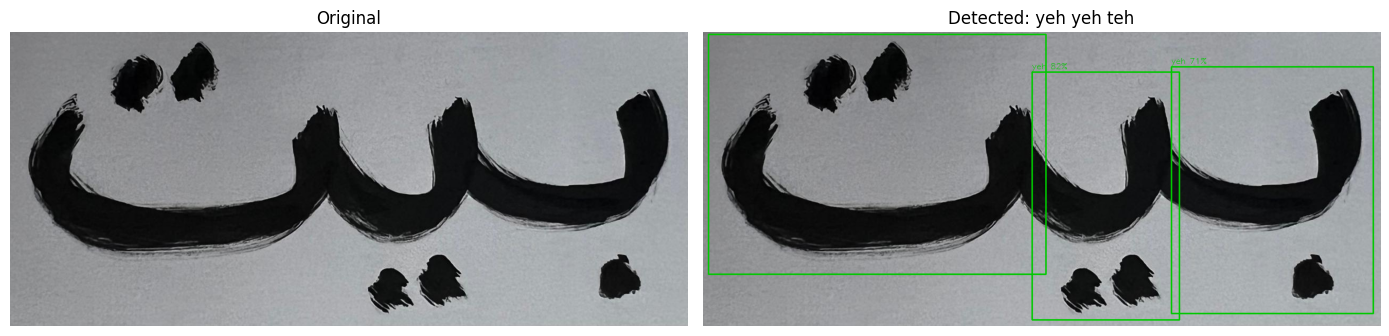

In [36]:
# ── Test on a single word image ───────────────────────────────
# Replace with your image path
TEST_IMAGE = str(ROOT / 'word_test.png')

chars, annotated = recognize_word(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4)

print(f"\nDetected characters (right → left): {chars}")
print(f"Word: {' '.join(chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: heh tah reh


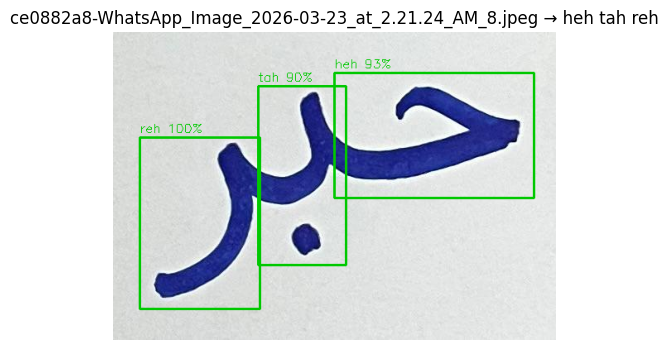

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: dad heh ghain


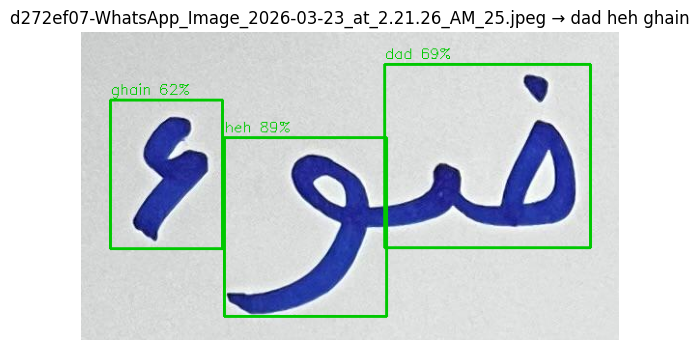

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: heh lam yeh


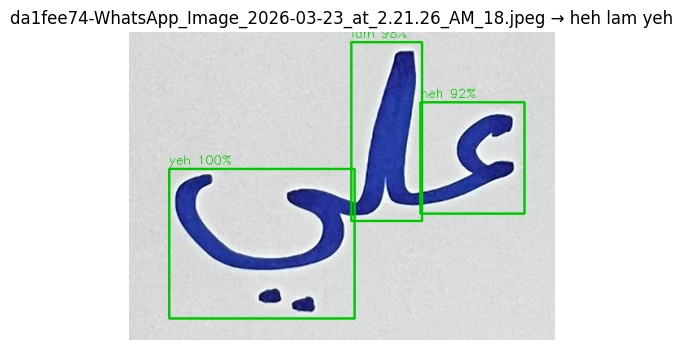

dd921431-WhatsApp_Image_2026-03-23_at_2.21.26_AM_20.jpeg: kaf heh lam waw


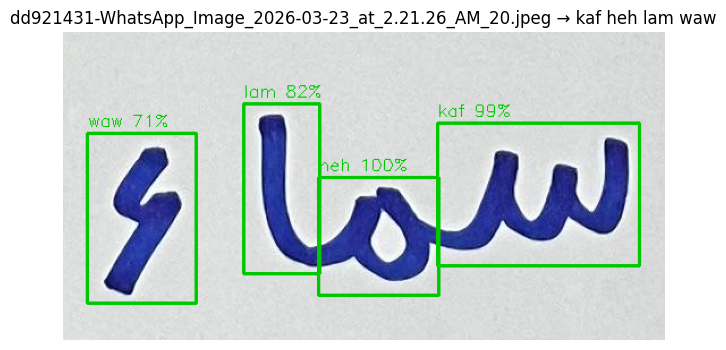

e05f66fa-WhatsApp_Image_2026-03-23_at_2.21.26_AM_9.jpeg: yeh alef ain


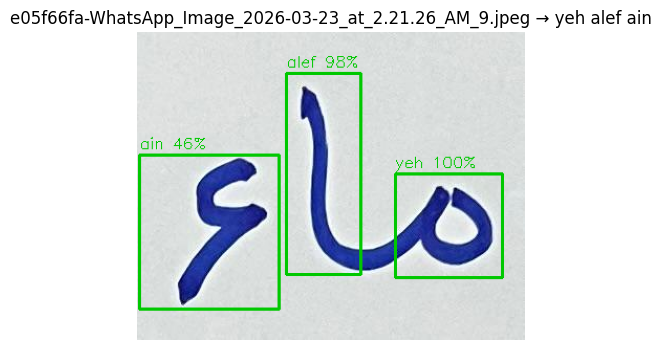

e47bdbbb-WhatsApp_Image_2026-03-23_at_2.21.26_AM_47.jpeg: heh zain


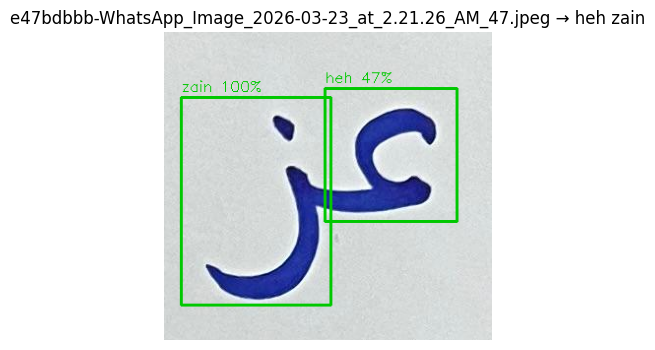

e8f36542-WhatsApp_Image_2026-03-23_at_2.21.26_AM_21.jpeg: tah tah beh


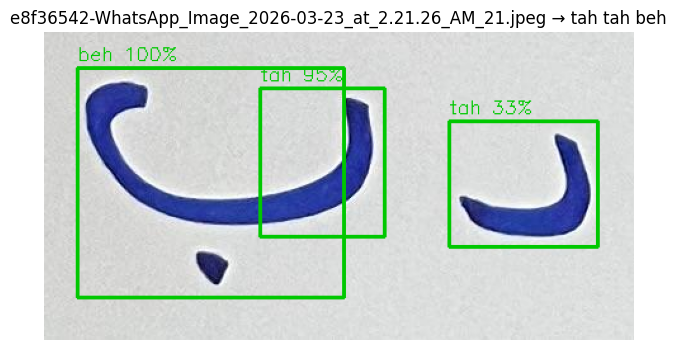

ee3eef31-WhatsApp_Image_2026-03-23_at_2.21.26_AM_40.jpeg: yeh dad feh


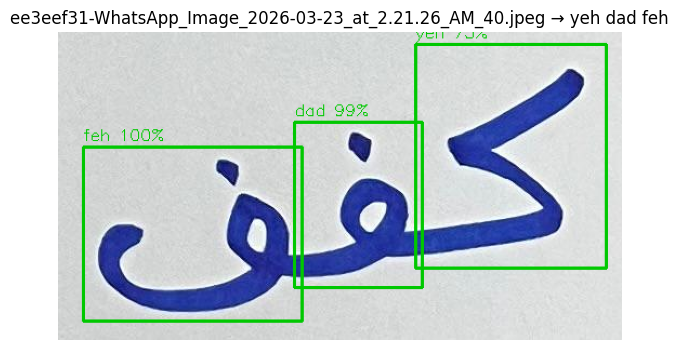

ef978434-WhatsApp_Image_2026-03-23_at_2.21.24_AM_1.jpeg: beh yeh teh


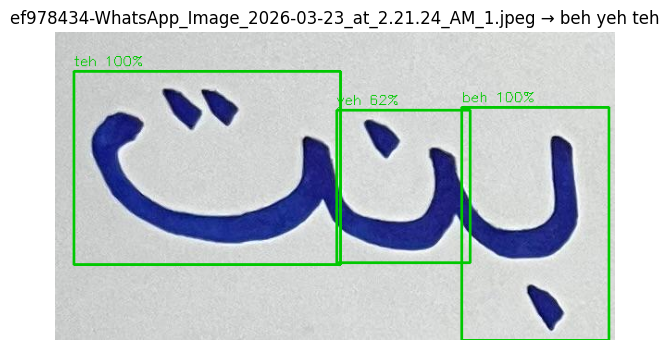

f1769f84-WhatsApp_Image_2026-03-23_at_2.21.26_AM_11.jpeg: kaf ghain lam


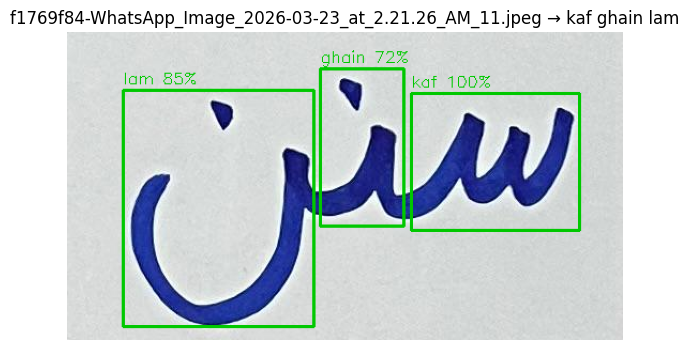

f2491bc4-WhatsApp_Image_2026-03-23_at_2.21.24_AM_3.jpeg: sad theh lam


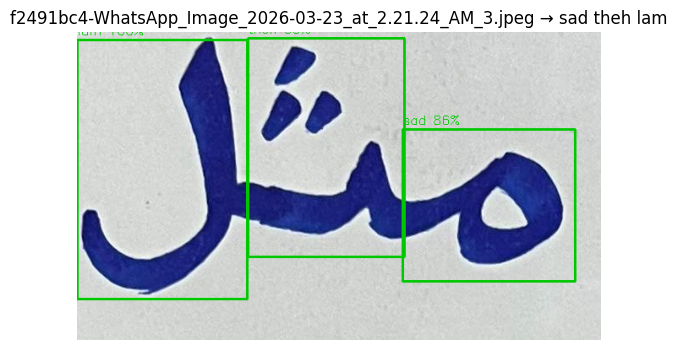

f84cf9b6-WhatsApp_Image_2026-03-23_at_2.21.26_AM_46.jpeg: tah heh zah qaf


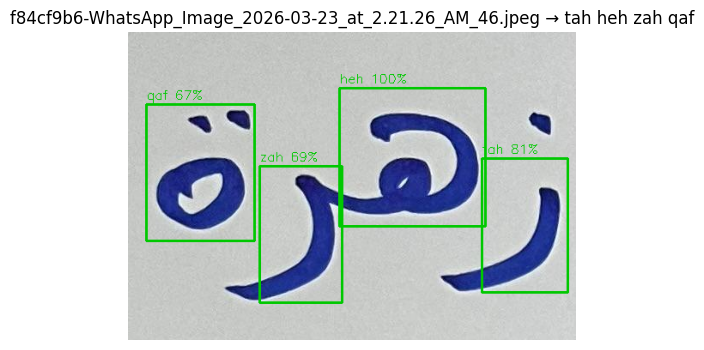

ffef08bc-WhatsApp_Image_2026-03-23_at_2.21.26_AM_34.jpeg: lam qaf beh


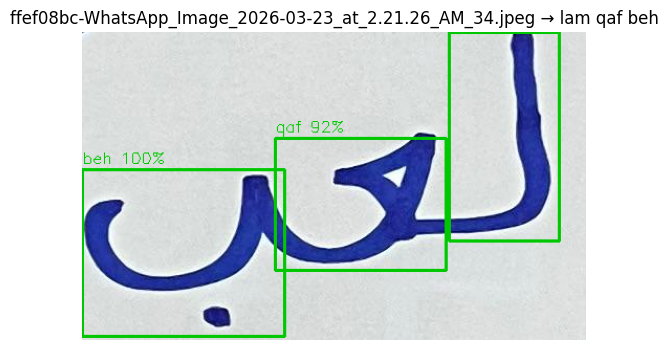

In [37]:
# ── Test on all val images ────────────────────────────────────
val_images = list((MY_DATASET / 'val' / 'images').glob('*.*'))
print(f"Testing on {len(val_images)} val images...\n")

for img_path in val_images:
    try:
        chars, annotated = recognize_word(str(img_path), conf_threshold=0.25)
        print(f"{img_path.name}: {' '.join(chars)}")
        plt.figure(figsize=(10, 4))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_path.name} → {' '.join(chars)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error on {img_path.name}: {e}")

YOLO found 3 boxes


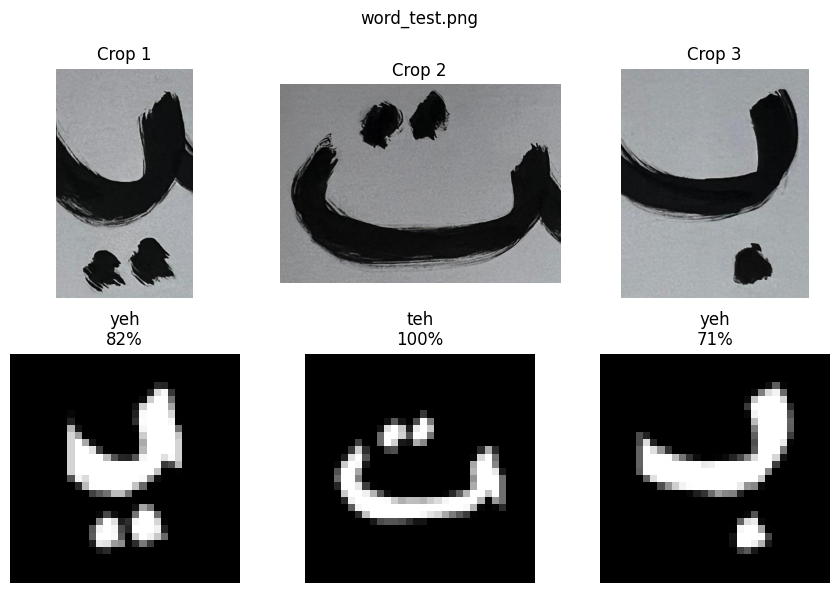

In [39]:
# ── Debug: visualise crops and CNN predictions ────────────────
def debug_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img  = cv2.imread(str(image_path))
    H, W = img.shape[:2]
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes   = results.boxes
    print(f"YOLO found {len(boxes)} boxes")

    n = len(boxes)
    if n == 0:
        return
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    if n == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = img[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        inp  = preprocess_crop_for_cnn(crop)

        axes[0][i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[0][i].set_title(f'Crop {i+1}'); axes[0][i].axis('off')

        if inp is not None:
            axes[1][i].imshow(inp[0], cmap='gray' if inp[0].shape[-1]==1 else None)
            preds = cnn_model.predict(inp, verbose=0)[0]
            idx   = np.argmax(preds)
            axes[1][i].set_title(f"{ARABIC_LABELS[idx]}\n{preds[idx]:.0%}")
        else:
            axes[1][i].set_title('None')
        axes[1][i].axis('off')

    plt.suptitle(Path(image_path).name)
    plt.tight_layout()
    plt.show()

# Run on your test image
debug_word(TEST_IMAGE)